# Setup

## MySql connection Test

In [ ]:
! pip install python-dotenv
! pip install haversine==2.8.1 mysql-connector-python==8.0.33 tabulate==0.9.0
! pip install mysql-connector-python pandas ipykernel
! pip install folium

In [ ]:
import mysql.connector as mysql
from tabulate import tabulate

class DbConnector:
    """
    Connects to the MySQL server on the Ubuntu virtual machine.
    """

    def __init__(self,
                 HOST="tdt4225-03.idi.ntnu.no",
                 DATABASE="db_A2_G3",
                 USER="DiegoT",
                 PASSWORD="G3Rocky"):
        self.db_connection = None
        self.cursor = None

        try:
            self.db_connection = mysql.connect(
                host=HOST,
                database=DATABASE,
                user=USER,
                password=PASSWORD,
                port=3306
            )
            self.cursor = self.db_connection.cursor()

            print("Connected to:", self.db_connection.get_server_info())
            self.cursor.execute("SELECT DATABASE();")
            database_name = self.cursor.fetchone()
            print("You are connected to the database:", database_name)
            print("-----------------------------------------------\n")

        except mysql.Error as e:
            print("ERROR: Failed to connect to db:", e)
            raise e  # Re-raise so main() handles setup failure cleanly

    def close_connection(self):
        if self.cursor:
            self.cursor.close()
        if self.db_connection and self.db_connection.is_connected():
            print("\n-----------------------------------------------")
            print("Connection to %s is closed" % self.db_connection.get_server_info())
            self.db_connection.close()


class ExampleProgram:

    def __init__(self):
        self.connection = DbConnector()
        self.db_connection = self.connection.db_connection
        self.cursor = self.connection.cursor

    def create_table(self, table_name):
        # Safely formatted SQL query template
        query = f"""CREATE TABLE IF NOT EXISTS {table_name} (
                   id INT AUTO_INCREMENT NOT NULL PRIMARY KEY,
                   name VARCHAR(30))"""
        self.cursor.execute(query)
        self.db_connection.commit()

    def insert_data(self, table_name):
        names = ['Bobby', 'Mc', 'McSmack', 'Board']
        # Recommended: Use parameterized queries to avoid syntax errors/SQL injection
        query = f"INSERT INTO {table_name} (name) VALUES (%s)"
        for name in names:
            self.cursor.execute(query, (name,))
        self.db_connection.commit()

    def fetch_data(self, table_name):
        query = f"SELECT * FROM {table_name}"
        self.cursor.execute(query)
        rows = self.cursor.fetchall()
        print("Data from table %s, raw format:" % table_name)
        print(rows)
        print("Data from table %s, tabulated:" % table_name)
        print(tabulate(rows, headers=self.cursor.column_names))
        return rows

    def drop_table(self, table_name):
        print("Dropping table %s..." % table_name)
        query = f"DROP TABLE {table_name}"
        self.cursor.execute(query)

    def show_tables(self):
        self.cursor.execute("SHOW TABLES")
        rows = self.cursor.fetchall()
        print(tabulate(rows, headers=self.cursor.column_names))


def main():
    program = None
    try:
        program = ExampleProgram()
        program.create_table(table_name="Person")
        program.insert_data(table_name="Person")
        _ = program.fetch_data(table_name="Person")
        program.drop_table(table_name="Person")
        program.show_tables()
    except Exception as e:
        print("ERROR: Failed to use database:", e)
    finally:
        if program and hasattr(program, 'connection'):
            program.connection.close_connection()


if __name__ == '__main__':
    main()

Connected to: 8.4.11-0ubuntu0.26.04.1
You are connected to the database: ('db_A2_G3',)
-----------------------------------------------

Data from table Person, raw format:
[(1, 'Bobby'), (2, 'Mc'), (3, 'McSmack'), (4, 'Board')]
Data from table Person, tabulated:
  id  name
----  -------
   1  Bobby
   2  Mc
   3  McSmack
   4  Board
Dropping table Person...
Tables_in_db_A2_G3
--------------------

-----------------------------------------------
Connection to 8.4.11-0ubuntu0.26.04.1 is closed


## Df load

In [1]:
DATA_PATH = "porto.csv"

In [2]:
import pandas as pd
import numpy as np

# ---- Load the dataframe ----
# Keep IDs-with-NULLs as nullable ints, and keep POLYLINE as a raw string for now
# (parsing 1.7M JSON lists is expensive, so we do it lazily / when needed).

dtypes = {
    "TRIP_ID": "Int64",
    "CALL_TYPE": "category",
    "ORIGIN_CALL": "Int64",
    "ORIGIN_STAND": "Int64",
    "TAXI_ID": "Int64",
    "TIMESTAMP": "Int64",
    "DAYTYPE": "category",
    "MISSING_DATA": "string",     # normalised to bool in the next cell
    "POLYLINE": "string",
}

df = pd.read_csv(DATA_PATH, dtype=dtypes)
df.columns = [c.strip().upper() for c in df.columns]   # tolerate header case/whitespace

# Part 1 EDA

In [12]:
# df copied to df_clean for cleaning and analysis, so we can keep the original df intact
df_clean = df.copy()

print(df_clean.shape)
df_clean.head()

(1710670, 9)


,TRIP_ID,CALL_TYPE,ORIGIN_CALL,ORIGIN_STAND,TAXI_ID,TIMESTAMP,DAY_TYPE,MISSING_DATA,POLYLINE
0,1372636858620000589,C,<NA>,<NA>,20000589,1372636858,A,False,"[[-8.618643,41.141412],[-8.618499,41.141376],[..."
1,1372637303620000596,B,<NA>,7,20000596,1372637303,A,False,"[[-8.639847,41.159826],[-8.640351,41.159871],[..."
2,1372636951620000320,C,<NA>,<NA>,20000320,1372636951,A,False,"[[-8.612964,41.140359],[-8.613378,41.14035],[-..."
3,1372636854620000520,C,<NA>,<NA>,20000520,1372636854,A,False,"[[-8.574678,41.151951],[-8.574705,41.151942],[..."
4,1372637091620000337,C,<NA>,<NA>,20000337,1372637091,A,False,"[[-8.645994,41.18049],[-8.645949,41.180517],[-..."


In [13]:
# ---- Basic cleaning ----
df_clean.info()

# MISSING_DATA -> real boolean
df_clean["MISSING_DATA"] = (
    df_clean["MISSING_DATA"].str.strip().str.lower().map({"true": True, "false": False})
).astype("boolean")

# TIMESTAMP (unix seconds) -> datetime
df_clean["START_TIME"] = pd.to_datetime(df_clean["TIMESTAMP"], unit="s")
df_clean.drop(columns=["TIMESTAMP"], inplace=True)

df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1710670 entries, 0 to 1710669
Data columns (total 9 columns):
 #   Column        Dtype   
---  ------        -----   
 0   TRIP_ID       Int64   
 1   CALL_TYPE     category
 2   ORIGIN_CALL   Int64   
 3   ORIGIN_STAND  Int64   
 4   TAXI_ID       Int64   
 5   TIMESTAMP     Int64   
 6   DAY_TYPE      object  
 7   MISSING_DATA  string  
 8   POLYLINE      string  
dtypes: Int64(5), category(1), object(1), string(2)
memory usage: 114.2+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1710670 entries, 0 to 1710669
Data columns (total 9 columns):
 #   Column        Dtype        
---  ------        -----        
 0   TRIP_ID       Int64        
 1   CALL_TYPE     category     
 2   ORIGIN_CALL   Int64        
 3   ORIGIN_STAND  Int64        
 4   TAXI_ID       Int64        
 5   DAY_TYPE      object       
 6   MISSING_DATA  boolean      
 7   POLYLINE      string       
 8   START_TIME    datetime64[s]
dtypes: Int64(4), boolean(1),

In [7]:
df_clean.describe(include='all')

,TRIP_ID,CALL_TYPE,ORIGIN_CALL,ORIGIN_STAND,TAXI_ID,DAY_TYPE,MISSING_DATA,POLYLINE,START_TIME
count,1710670.0,1710670,364770.0,806579.0,1710670.0,1710670,1710670,1710670,1710670
unique,<NA>,3,<NA>,<NA>,<NA>,1,2,1703650,NaN
top,<NA>,B,<NA>,<NA>,<NA>,A,False,[],NaN
freq,<NA>,817881,<NA>,<NA>,<NA>,1710670,1710660,5901,NaN
mean,1388622387803249152.0,NaN,24490.363018,30.272381,20000348.531181,NaN,NaN,NaN,2014-01-02 00:26:27
min,1372636853620000256.0,NaN,2001.0,1.0,20000001.0,NaN,NaN,NaN,2013-07-01 00:00:53
25%,1380730539120000256.0,NaN,6593.0,15.0,20000166.0,NaN,NaN,NaN,2013-10-02 16:15:38
50%,1388492544120000000.0,NaN,18755.0,27.0,20000345.0,NaN,NaN,NaN,2013-12-31 12:22:23
75%,1396750457120000256.0,NaN,40808.0,49.0,20000520.0,NaN,NaN,NaN,2014-04-06 02:14:16
max,1404172796620000768.0,NaN,63884.0,63.0,20000981.0,NaN,NaN,NaN,2014-06-30 23:59:56


In [8]:
print("Rows:", len(df_clean))
print("Unique taxis:", df_clean["TAXI_ID"].nunique())
print("Unique trip ids:", df_clean["TRIP_ID"].nunique())
print("\nNulls per column:\n", df_clean.isna().sum())
print("\nCALL_TYPE:\n", df_clean["CALL_TYPE"].value_counts(dropna=False))
print("\nDAYTYPE:\n", df_clean["DAY_TYPE"].value_counts(dropna=False))
print("\nMISSING_DATA:\n", df_clean["MISSING_DATA"].value_counts(dropna=False))

Rows: 1710670
Unique taxis: 448
Unique trip ids: 1710589

Nulls per column:
 TRIP_ID               0
CALL_TYPE             0
ORIGIN_CALL     1345900
ORIGIN_STAND     904091
TAXI_ID               0
DAY_TYPE              0
MISSING_DATA          0
POLYLINE              0
START_TIME            0
dtype: int64

CALL_TYPE:
 CALL_TYPE
B    817881
C    528019
A    364770
Name: count, dtype: int64

DAYTYPE:
 DAY_TYPE
A    1710670
Name: count, dtype: int64

MISSING_DATA:
 MISSING_DATA
False    1710660
True          10
Name: count, dtype: Int64


In [22]:
# Duplicate Trips
print("Number of duplicate trips:", df_clean.duplicated(subset=["TRIP_ID"]).sum())

# Show duplicate trip 
print("\n",df_clean[df_clean.duplicated(subset=["TRIP_ID"], keep=False)].sort_values(by=["TRIP_ID", "START_TIME"]))

# Same trip id but different polyline ?
print("\nNumber of duplicate trips:", df_clean.duplicated(subset=["TRIP_ID","POLYLINE"]).sum())

Number of duplicate trips: 81

                      TRIP_ID CALL_TYPE  ORIGIN_CALL  ORIGIN_STAND   TAXI_ID  \
3519     1372702836620000080         B         <NA>            16  20000080   
3720     1372702836620000080         C         <NA>          <NA>  20000080   
21282    1373025987620000601         A         2002          <NA>  20000601   
21385    1373025987620000601         C         <NA>          <NA>  20000601   
33228    1373210896620000598         B         <NA>            57  20000598   
...                      ...       ...          ...           ...       ...   
1665302  1403407180620000242         C         <NA>          <NA>  20000242   
1684526  1403716904620000337         C         <NA>          <NA>  20000337   
1684739  1403716904620000337         C         <NA>          <NA>  20000337   
1705646  1404093316620000307         B         <NA>            57  20000307   
1705665  1404093316620000307         C         <NA>          <NA>  20000307   

        DAY_TYPE  M

In [11]:
""" 
Verify origin call and stand statements:
ORIGIN_CALL: ID of the client who initiated the call (only set when CALL_TYPE = A). Otherwise NULL.
ORIGIN_STAND: Taxi stand ID where the trip started (only set when CALL_TYPE = B). Otherwise NULL.
"""

# 1. Validation Logic
origin_call_valid = (
    df_clean[df_clean['CALL_TYPE'] == 'A']['ORIGIN_CALL'].notna().all() and
    df_clean[df_clean['CALL_TYPE'] != 'A']['ORIGIN_CALL'].isna().all()
)

origin_stand_valid = (
    df_clean[df_clean['CALL_TYPE'] == 'B']['ORIGIN_STAND'].notna().all() and
    df_clean[df_clean['CALL_TYPE'] != 'B']['ORIGIN_STAND'].isna().all()
)

print(f"ORIGIN_CALL condition valid: {origin_call_valid}")
print(f"ORIGIN_STAND condition valid: {origin_stand_valid}\n")

# 2. Detailed Breakdown Table (observed=False silences the FutureWarning)
summary = df_clean.groupby('CALL_TYPE', observed=False).agg(
    TOTAL_TRIPS=('CALL_TYPE', 'count'),
    ORIGIN_CALL_NON_NULL=('ORIGIN_CALL', 'count'),
    ORIGIN_STAND_NON_NULL=('ORIGIN_STAND', 'count')
)

# Calculate missing stand IDs for CALL_TYPE 'B'
summary['ORIGIN_STAND_MISSING'] = summary.apply(
    lambda row: row['TOTAL_TRIPS'] - row['ORIGIN_STAND_NON_NULL'] if row.name == 'B' else 0, 
    axis=1
)

print("--- Data Completeness Breakdown ---")
print(summary)

ORIGIN_CALL condition valid: True
ORIGIN_STAND condition valid: False

--- Data Completeness Breakdown ---
           TOTAL_TRIPS  ORIGIN_CALL_NON_NULL  ORIGIN_STAND_NON_NULL  \
CALL_TYPE                                                             
A               364770                364770                      0   
B               817881                     0                 806579   
C               528019                     0                      0   

           ORIGIN_STAND_MISSING  
CALL_TYPE                        
A                             0  
B                         11302  
C                             0  


In [ ]:
# Origin stand and taxi id sample
df_clean[df_clean['CALL_TYPE'] == 'B'][['ORIGIN_STAND', 'TAXI_ID', 'POLYLINE']].sample(10, random_state=42)

,ORIGIN_STAND,TAXI_ID,POLYLINE
1523845,31,20000060,"[[-8.66376,41.177187],[-8.663328,41.177673],[-..."
740726,33,20000406,"[[-8.600112,41.182722],[-8.60013,41.182677],[-..."
1444873,<NA>,20000487,"[[-8.619867,41.148027],[-8.619885,41.148045],[..."
1632629,36,20000693,"[[-8.649018,41.154903],[-8.649009,41.154876],[..."
805201,63,20000352,"[[-8.609652,41.160411],[-8.609634,41.16042],[-..."
586987,6,20000687,"[[-8.5824,41.180526],[-8.582184,41.180382],[-8..."
1516763,34,20000670,"[[-8.615556,41.140656],[-8.615565,41.140638],[..."
636256,18,20000142,"[[-8.619804,41.148045],[-8.619813,41.148054],[..."
121003,12,20000664,"[[-8.63064,41.154957],[-8.630694,41.154894],[-..."
725908,11,20000507,"[[-8.613171,41.1669],[-8.613198,41.16681],[-8...."


In [ ]:
import json
import pandas as pd
import numpy as np

# -------------------------------------------------------------------------
# CHECK 1: Does each TAXI_ID always use the same ORIGIN_STAND?
# -------------------------------------------------------------------------
stand_per_taxi = (
    df_clean[df_clean['CALL_TYPE'] == 'B']
    .groupby('TAXI_ID')['ORIGIN_STAND']
    .nunique()
)

print("=== CHECK 1: TAXI_ID vs. ORIGIN_STAND ===")
print(f"Total taxis serving type 'B' trips: {len(stand_per_taxi)}")
print(f"Taxis that use ONLY 1 stand:       {(stand_per_taxi == 1).sum()}")
print(f"Taxis that use multiple (>1) stands: {(stand_per_taxi > 1).sum()}")
print(f"Max stands used by a single taxi:  {stand_per_taxi.max()}\n")


# -------------------------------------------------------------------------
# CHECK 2: Does the first POLYLINE coordinate stay the same for each stand?
# -------------------------------------------------------------------------

# Helper to safely extract start coordinate [lon, lat]
def extract_start_coord(polyline):
    if pd.isna(polyline) or polyline in ('[]', ''):
        return None, None
    try:
        pts = json.loads(polyline) if isinstance(polyline, str) else polyline
        if pts and len(pts) > 0:
            return float(pts[0][0]), float(pts[0][1])
    except Exception:
        pass
    return None, None

# Extract starting longitude and latitude
coords = df_clean['POLYLINE'].apply(extract_start_coord)
df_clean['START_LON'] = [c[0] for c in coords]
df_clean['START_LAT'] = [c[1] for c in coords]

# Analyze coordinate clustering per stand for valid CALL_TYPE == 'B'
stand_geo_stats = (
    df_clean[(df_clean['CALL_TYPE'] == 'B') & df_clean['ORIGIN_STAND'].notna()]
    .groupby('ORIGIN_STAND', observed=False)
    .agg(
        TRIP_COUNT=('TRIP_ID', 'count'),
        UNIQUE_COORDS=('START_LON', lambda x: len(set(zip(x, df_clean.loc[x.index, 'START_LAT'])))),
        LON_MEAN=('START_LON', 'mean'),
        LAT_MEAN=('START_LAT', 'mean'),
        LON_STD=('START_LON', 'std'),
        LAT_STD=('START_LAT', 'std')
    )
)

print("=== CHECK 2: STARTING COORDINATES PER STAND ===")
print(stand_geo_stats.head(10))

=== CHECK 1: TAXI_ID vs. ORIGIN_STAND ===
Total taxis serving type 'B' trips: 439
Taxis that use ONLY 1 stand:       1
Taxis that use multiple (>1) stands: 438
Max stands used by a single taxi:  61

=== CHECK 2: STARTING COORDINATES PER STAND ===
              TRIP_COUNT  UNIQUE_COORDS  LON_MEAN   LAT_MEAN   LON_STD  \
ORIGIN_STAND                                                             
1                   4518           1165 -8.609420  41.177267  0.000903   
2                   1191            324 -8.591413  41.156215  0.001490   
3                   3559            710 -8.665592  41.170685  0.001120   
4                   1153            764 -8.621561  41.143637  0.000895   
5                     53             52 -8.613193  41.183544  0.002418   
6                  16639           5394 -8.582638  41.180695  0.034408   
7                  18557           2828 -8.639859  41.159775  0.000857   
8                    381            203 -8.568492  41.151614  0.002007   
9            

In [ ]:
import numpy as np
import pandas as pd
from scipy.spatial import KDTree

# 1. Filter valid stands with non-null start coordinates
valid_b_trips = df_clean[
    (df_clean['CALL_TYPE'] == 'B') & 
    (df_clean['ORIGIN_STAND'].notna()) & 
    (df_clean['START_LON'].notna()) & 
    (df_clean['START_LAT'].notna())
]

# 2. Compute stand centroids (mean start position for each stand)
stand_centroids = (
    valid_b_trips
    .groupby('ORIGIN_STAND', observed=False)[['START_LON', 'START_LAT']]
    .mean()
    .reset_index()
)

# 3. Build spatial KDTree using reference stand locations
tree = KDTree(stand_centroids[['START_LON', 'START_LAT']].values)

# 4. Identify missing ORIGIN_STAND indices for CALL_TYPE 'B'
missing_mask = (
    (df_clean['CALL_TYPE'] == 'B') & 
    (df_clean['ORIGIN_STAND'].isna()) & 
    (df_clean['START_LON'].notna()) & 
    (df_clean['START_LAT'].notna())
)

missing_coords = df_clean.loc[missing_mask, ['START_LON', 'START_LAT']].values

# 5. Query nearest stand ID for each missing point
if len(missing_coords) > 0:
    distances, indices = tree.query(missing_coords)
    assigned_stands = stand_centroids.iloc[indices]['ORIGIN_STAND'].values
    
    # Fill missing values
    df_clean.loc[missing_mask, 'ORIGIN_STAND'] = assigned_stands

# 6. Verify final completeness
missing_remaining = df_clean[df_clean['CALL_TYPE'] == 'B']['ORIGIN_STAND'].isna().sum()
print(f"Remaining missing ORIGIN_STAND for CALL_TYPE 'B': {missing_remaining}")

Remaining missing ORIGIN_STAND for CALL_TYPE 'B': 20


In [ ]:
import folium
from folium.plugins import MarkerCluster

# 1. Calculate stand centroids and total trip volume
stand_centroids = (
    df_clean[
        (df_clean['CALL_TYPE'] == 'B') & 
        (df_clean['ORIGIN_STAND'].notna()) & 
        (df_clean['START_LON'].notna()) & 
        (df_clean['START_LAT'].notna())
    ]
    .groupby('ORIGIN_STAND', observed=False)
    .agg(
        LON=('START_LON', 'mean'),
        LAT=('START_LAT', 'mean'),
        TRIP_COUNT=('TRIP_ID', 'count')
    )
    .reset_index()
)

# 2. Create base map centered on Porto, Portugal
porto_map = folium.Map(
    location=[41.1501, -8.6103], 
    zoom_start=13, 
    tiles='OpenStreetMap'
)

# 3. Add clustered or circle markers for each stand
marker_cluster = MarkerCluster().add_to(porto_map)

for _, row in stand_centroids.iterrows():
    stand_id = int(row['ORIGIN_STAND'])
    trips = int(row['TRIP_COUNT'])
    lat, lon = row['LAT'], row['LON']
    
    folium.CircleMarker(
        location=[lat, lon],
        radius=min(15, max(4, trips // 2000)),  # Size scaled by popularity
        popup=f"<b>Taxi Stand {stand_id}</b><br>Total Trips: {trips:,}",
        color='#2b8cbe',
        fill=True,
        fill_color='#7bccc4',
        fill_opacity=0.7
    ).add_to(marker_cluster)

# Display in Jupyter notebook
porto_map

/Users/diegotorresbravo/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


/var/folders/vl/xlcg7z052993rf2f_9vpl4h00000gn/T/ipykernel_52997/407228700.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=call_counts.index, y=call_counts.values, ax=axes[0, 0], palette='Blues_r')
/var/folders/vl/xlcg7z052993rf2f_9vpl4h00000gn/T/ipykernel_52997/407228700.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=day_counts.index, y=day_counts.values, ax=axes[0, 1], palette='Greens_r')
/var/folders/vl/xlcg7z052993rf2f_9vpl4h00000gn/T/ipykernel_52997/407228700.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_b

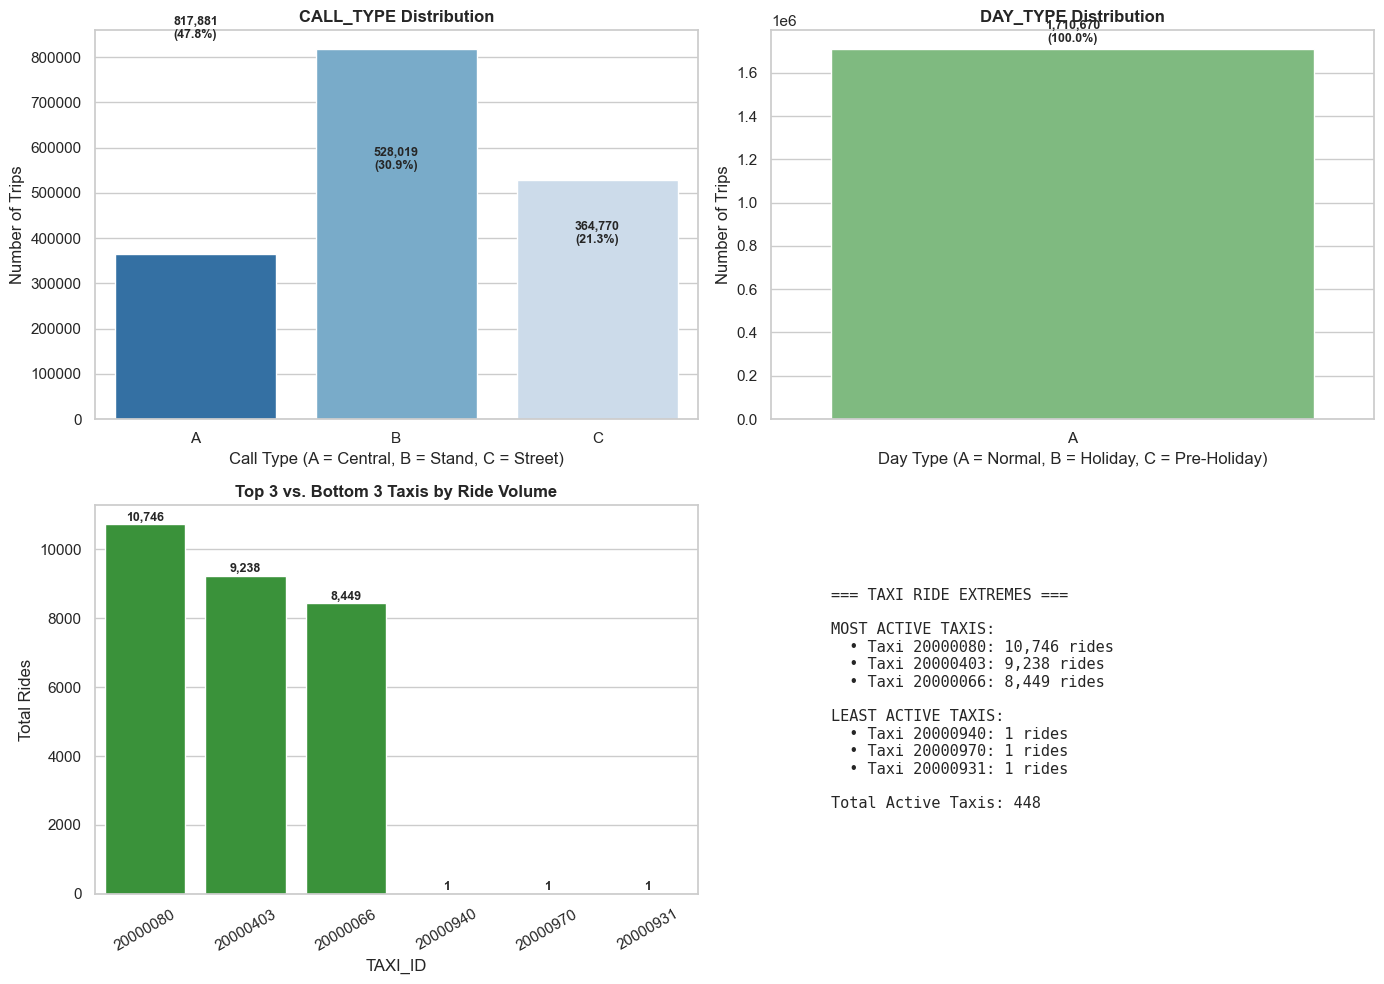

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set plotting style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# -------------------------------------------------------------------------
# 1. CALL_TYPE Distribution
# -------------------------------------------------------------------------
call_counts = df_clean['CALL_TYPE'].value_counts()
total_trips = len(df_clean)

sns.barplot(x=call_counts.index, y=call_counts.values, ax=axes[0, 0], palette='Blues_r')
axes[0, 0].set_title('CALL_TYPE Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Call Type (A = Central, B = Stand, C = Street)')
axes[0, 0].set_ylabel('Number of Trips')

for i, count in enumerate(call_counts.values):
    pct = (count / total_trips) * 100
    axes[0, 0].text(i, count + (total_trips * 0.01), f"{count:,}\n({pct:.1f}%)", 
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

# -------------------------------------------------------------------------
# 2. DAY_TYPE Distribution
# -------------------------------------------------------------------------
day_col = 'DAY_TYPE' if 'DAY_TYPE' in df_clean.columns else 'DAYTYPE'
day_counts = df_clean[day_col].value_counts()

sns.barplot(x=day_counts.index, y=day_counts.values, ax=axes[0, 1], palette='Greens_r')
axes[0, 1].set_title('DAY_TYPE Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Day Type (A = Normal, B = Holiday, C = Pre-Holiday)')
axes[0, 1].set_ylabel('Number of Trips')

for i, count in enumerate(day_counts.values):
    pct = (count / total_trips) * 100
    axes[0, 1].text(i, count + (total_trips * 0.01), f"{count:,}\n({pct:.1f}%)", 
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

# -------------------------------------------------------------------------
# 3. Top 3 and Bottom 3 Taxis by Number of Rides
# -------------------------------------------------------------------------
taxi_counts = df_clean['TAXI_ID'].value_counts()
top_3_taxis = taxi_counts.head(3)
bottom_3_taxis = taxi_counts.tail(3)

# Combine Top 3 and Bottom 3 into a single DataFrame for plotting
top_bottom_df = pd.concat([
    pd.DataFrame({'TAXI_ID': top_3_taxis.index.astype(str), 'RIDE_COUNT': top_3_taxis.values, 'GROUP': 'Top 3'}),
    pd.DataFrame({'TAXI_ID': bottom_3_taxis.index.astype(str), 'RIDE_COUNT': bottom_3_taxis.values, 'GROUP': 'Bottom 3'})
])

colors = ['#2ca02c' if g == 'Top 3' else '#d62728' for g in top_bottom_df['GROUP']]

sns.barplot(data=top_bottom_df, x='TAXI_ID', y='RIDE_COUNT', ax=axes[1, 0], palette=colors)
axes[1, 0].set_title('Top 3 vs. Bottom 3 Taxis by Ride Volume', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('TAXI_ID')
axes[1, 0].set_ylabel('Total Rides')
axes[1, 0].tick_params(axis='x', rotation=30)

for i, row in enumerate(top_bottom_df.itertuples()):
    axes[1, 0].text(i, row.RIDE_COUNT + 10, f"{row.RIDE_COUNT:,}", 
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

# -------------------------------------------------------------------------
# 4. Stand-Alone Text Summary Card in the 4th Slot
# -------------------------------------------------------------------------
axes[1, 1].axis('off')

top_str = "\n".join([f"  • Taxi {tid}: {cnt:,} rides" for tid, cnt in top_3_taxis.items()])
bot_str = "\n".join([f"  • Taxi {tid}: {cnt:,} rides" for tid, cnt in bottom_3_taxis.items()])

summary_text = (
    f"=== TAXI RIDE EXTREMES ===\n\n"
    f"MOST ACTIVE TAXIS:\n{top_str}\n\n"
    f"LEAST ACTIVE TAXIS:\n{bot_str}\n\n"
    f"Total Active Taxis: {df_clean['TAXI_ID'].nunique():,}"
)

axes[1, 1].text(0.1, 0.5, summary_text, fontsize=11, family='monospace', va='center')

plt.tight_layout()
plt.show()